In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.signal import find_peaks, correlation_lags
from scipy.optimize import curve_fit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ExpSineSquared, CompoundKernel, RBF, WhiteKernel, ConstantKernel, Matern, RationalQuadratic, DotProduct
from sklearn.linear_model import Lasso, LinearRegression, ElasticNet, Ridge
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from statsmodels.graphics.tsaplots import plot_ccf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

To do:
- find missing value imputation strategies + indicator variabl
- First classification to determine whether the time point is a "normal" time point (periodic with gaussian noise) or a shock/spike time point
- Visualize the time points when spikes appear, see if there is a pattern to it.
- potentially tune the strength of the prior/number of frequencies as a hyperparameter

## Loading the data

In [3]:
splits = {'train': 'train.csv', 'validation': 'validation_input.csv'}
#df_train = pd.read_csv("hf://datasets/AIML-TUDA/dlam-ts-project-data-2026/" + splits["train"])
df_val = pd.read_csv("hf://datasets/AIML-TUDA/dlam-ts-project-data-2026/" + splits["validation"])

In [5]:
df_val.groupby("series_id").size()

series_id
unit_000    336
unit_001    336
unit_002    336
unit_003    336
unit_004    336
           ... 
unit_091    336
unit_092    336
unit_093    336
unit_094    336
unit_095    336
Length: 96, dtype: int64

In [6]:
df = pd.read_csv('train_split.csv', index_col=0)

In [8]:
df.groupby("series_id").size()

series_id
unit_000    4320
unit_001    4320
unit_002    4320
unit_003    4320
unit_004    4320
            ... 
unit_091    4320
unit_092    4320
unit_093    4320
unit_094    4320
unit_095    4320
Length: 96, dtype: int64

In [4]:
df.head(5)

,series_id,timestamp,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,trend,workload_intensity,demand_forecast,...,unit_reliability_forecast,queue_pressure_forecast,network_pressure_forecast,event_load_forecast,service_irregularity_risk_forecast,throughput_disruption_risk_forecast,nominal_capacity,zone_sin,zone_cos,target
0,unit_000,2023-01-01 00:00:00,0.000000,1.000000,-0.781831,0.62349,1.0,-1.731704,0.001633,0.027929,...,1.000000,1.768614,0.818472,0.160134,0.000000,0.063503,82.690278,0.0,1.0,2.989556
1,unit_000,2023-01-01 01:00:00,0.258819,0.965926,-0.781831,0.62349,1.0,-1.731010,0.004694,0.000000,...,0.887202,1.806212,1.816860,0.004240,0.080810,0.000000,82.690278,0.0,1.0,3.199527
2,unit_000,2023-01-01 02:00:00,0.500000,0.866025,-0.781831,0.62349,1.0,-1.730316,0.012069,0.110750,...,0.986113,NaN,2.596726,0.208973,0.000000,0.009573,82.690278,0.0,1.0,3.425670
3,unit_000,2023-01-01 03:00:00,0.707107,0.707107,-0.781831,0.62349,1.0,-1.729622,0.027770,0.164394,...,0.969943,2.778944,1.857860,0.241452,0.064186,0.000000,82.690278,0.0,1.0,3.133322
4,unit_000,2023-01-01 04:00:00,0.866025,0.500000,-0.781831,0.62349,1.0,-1.728928,0.057179,0.000000,...,0.901797,1.156086,2.489084,0.000000,0.000000,0.017581,82.690278,0.0,1.0,2.535954


In [143]:
split_percentage = 0.80

group_sizes = df.groupby("series_id")["series_id"].transform("size")
train_mask = (df.groupby("series_id").cumcount() / group_sizes) < split_percentage

df_train = df[train_mask].reset_index(drop=True)
df_val = df[~train_mask].reset_index(drop=True)

## Exploring priors for the Deep Learning Model

Here we investigate whether there is any significant structure in the data that can be used to construct a strong prior for the deep learning model. A strong prior has the following advantages:
- meaningful bias, less variance => less overfitting
- better sample efficiency due to reduced search space for the deep learning model. Also removes uninformative variance from the priodic structure captured by the prior. Residual learning also is empirically found to lead to faster training and more stable convergence. We don't want the model to "waste" most of its learning capacity on learning obvious patterns.
- interpretability: decomposes the model into interpretable pieces. $y_t = \text{prior}_t + \text{residual}_t$.
- makes diagnosing failures easier. Easy to see whether the model fails due to the periodic prior component, whether it fails to predict rare events. residual structure also carries more meaning and we can decompose the error into "normal" period errors and "special" period errors (e.g. shock events) to diagnose which events the model struggles with most. Let's us also diagnose whether the residual model overfits on noise. We can compare baseline only and baseline + residual performance on the validation set to see whether the residual model actually leads to performance gain. If not, then its likely overfitting on noise
- let's the network focus on the areas where deep learning is the most useful: nonlinear interactions, regime changes, long range forecasting of rare events

### Fourier Analysis

unit_014: Nr. of selected peaks = 23
unit_040: Nr. of selected peaks = 17
unit_057: Nr. of selected peaks = 21
unit_038: Nr. of selected peaks = 25
unit_044: Nr. of selected peaks = 19


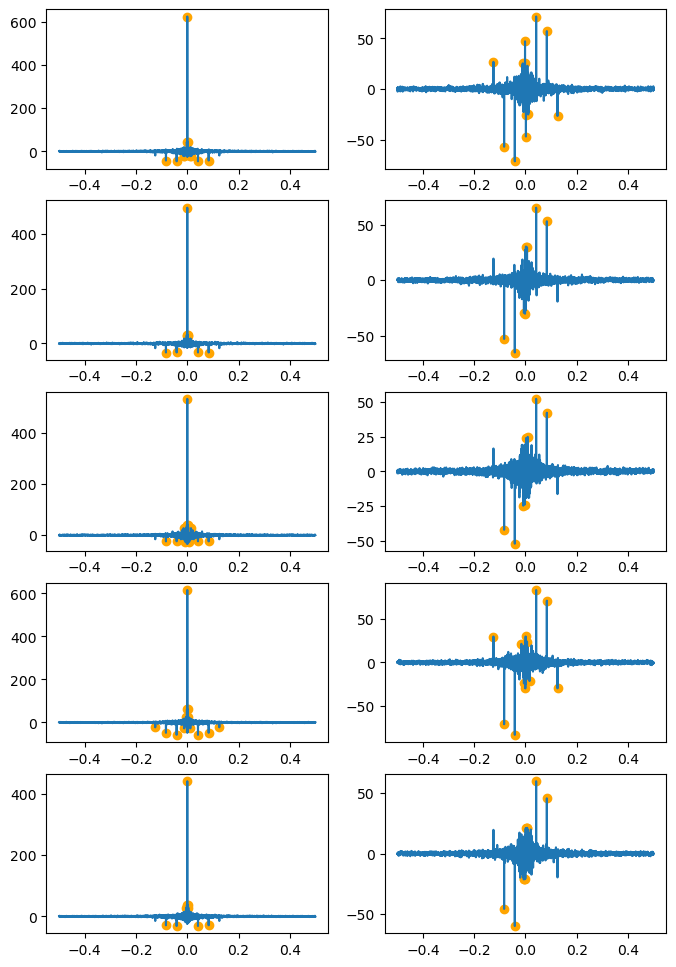

In [147]:
random_series = np.random.choice(df_train["series_id"].unique(),5)

fig, axs = plt.subplots(len(random_series),2, figsize=(8, 12))

for idx, unit in enumerate(random_series):
    current_series = df_train.loc[df_train["series_id"]==unit,"target"]
    target_f = np.fft.fft(current_series, norm='ortho')
    freqs=np.fft.fftfreq(len(target_f))

    peaks_real = find_peaks(np.fft.fftshift(np.abs(target_f.real)), prominence=20)
    peaks_imag = find_peaks(np.fft.fftshift(np.abs(target_f.imag)), prominence=20)

    axs[idx, 0].plot(np.fft.fftshift(freqs), np.fft.fftshift(np.real(target_f)))
    axs[idx, 0].scatter(np.fft.fftshift(freqs)[peaks_real[0]], np.fft.fftshift(np.real(target_f))[peaks_real[0]], color='orange')
    
    axs[idx, 1].plot(np.fft.fftshift(freqs), np.fft.fftshift(np.imag(target_f)))
    axs[idx, 1].scatter(np.fft.fftshift(freqs)[peaks_imag[0]], np.fft.fftshift(np.imag(target_f))[peaks_imag[0]], color='orange')
    
    print(f"{unit}: Nr. of selected peaks = {len(peaks_real[0])+len(peaks_imag[0])}")

In [148]:
print("Nr. of total frequencies:", len(freqs))

Nr. of total frequencies: 3456


Because the frequencies always appear symmetrically one time with a plus and one time with a minus sign and we only need half of the spectrum, this suggests that approximately just a few out of the 414720 Frequencies could already be enough to reconstruct a significant portion of the signal!

Let us now see whether that is the case. The reconstructed time series $T_r$ from a set of positive frequencies $\mathcal{F}$ is given by
$$T_r(t) = \frac{\widehat{T}(f=0)}{\sqrt{N}}+\sum_{f\in \mathcal{F}} 2\frac{|\widehat{T}(f)|}{\sqrt{N}}\cos{(2\pi f t+\phi_f)}$$

In [149]:
def forecast_prior(t, train_spectrum, freqs, cutoff=0):
    N = len(train_spectrum)
    y = np.zeros(len(t))
    count=0
    if np.abs(train_spectrum[0]) >= cutoff:
        count+=1
        y+= train_spectrum[0].real / np.sqrt(N)

    pos = np.where((freqs > 0) & (freqs < 0.5))[0]
    for k in pos:
        if np.abs(X[k]) >= cutoff:
            count += 1
            y += 2*np.abs(X[k])/np.sqrt(N)*np.cos(2*np.pi*freqs[k]*t+np.angle(X[k]))

    if N%2==0:
        k=N//2
        if np.abs(X[k]) >= cutoff:
            count+=1
            y += X[k].real/np.sqrt(N)*np.cos(np.pi*t)
    return y

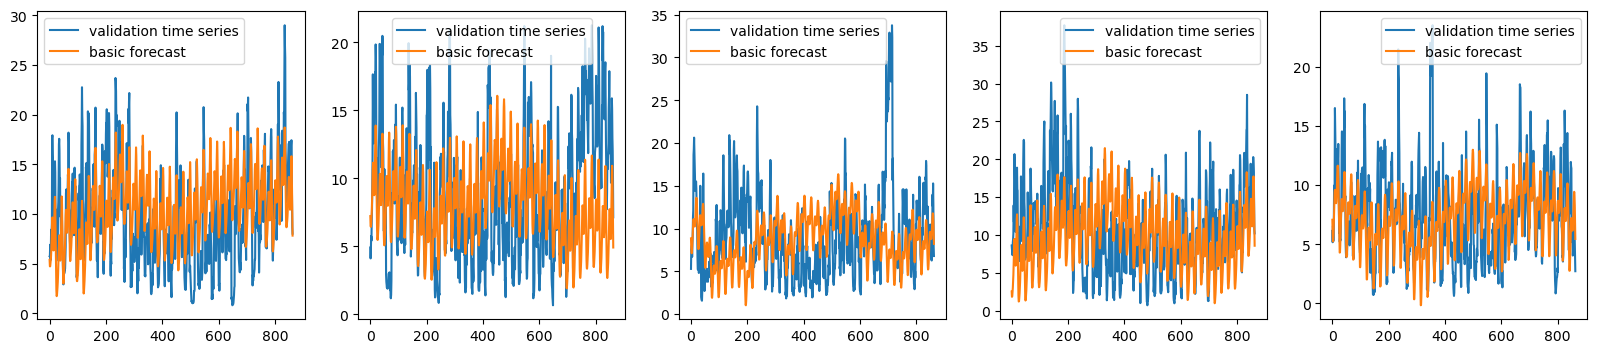

In [184]:
fig, axs = plt.subplots(1,5, figsize=(20,4))
for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit, "target"].to_numpy()
    X = np.fft.fft(x_train, norm="ortho")
    freqs = np.fft.fftfreq(len(X))
    
    n_train = np.arange(len(x_train))
    x_recon = forecast_prior(df_val.loc[df_val["series_id"]==unit].index.to_numpy(), X, freqs, cutoff=25)
    axs[idx].plot(df_val.loc[df_val["series_id"]==unit,"target"].to_numpy(), label="validation time series")
    axs[idx].plot(x_recon, label="basic forecast")
    #axs[idx].set_xlim(0,200)
    axs[idx].legend()

Clearly the Fourier reconstruction captures a significant portion of the periodicity in the data. However it is missing unexpected amplitude fluctuations and large shocks/spikes, which is expected. Let's have a look at the out-of-sample residuals. 

Residual mean:  -0.891612013741729
Residual std:  5.167006595526546
Residual mean:  1.0414045739343722
Residual std:  4.425318002433083
Residual mean:  0.5742055592008466
Residual std:  6.107648036767646
Residual mean:  1.632820037971243
Residual std:  5.824817432695989
Residual mean:  0.8718581439083773
Residual std:  3.5379198065767063


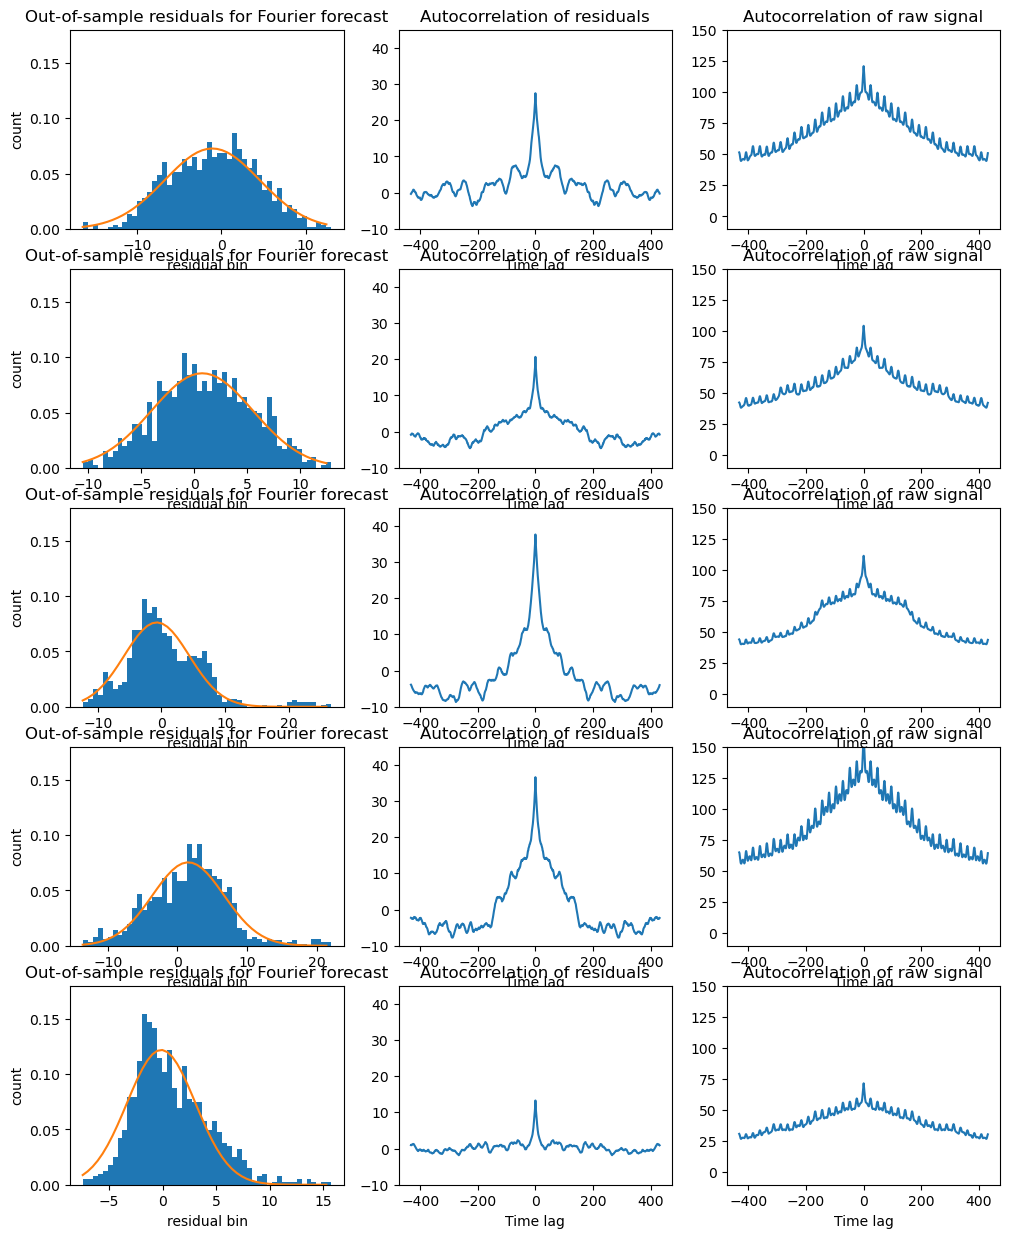

In [185]:
def gaussian(x, A, mu, sig):
    return A*np.exp(-((x-mu)/(2*sig))**2)

fig, axs = plt.subplots(5,3,figsize=(12,15))

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit, "target"].to_numpy()
    X = np.fft.fft(x_train, norm="ortho")
    freqs = np.fft.fftfreq(len(X))
    
    n_train = np.arange(len(x_train))
    x_recon = forecast_prior(df_val.loc[df_val["series_id"]==unit].index.to_numpy(), X, freqs, cutoff=15)

    res = df_val.loc[df_val["series_id"]==unit,'target']-x_recon
    res_hist, bin_edges = np.histogram(res, bins=50, density=True)

    gauss_fit = curve_fit(gaussian, bin_edges[:-1], res_hist, p0=[0.15,-3,8])
    fitted_gauss = gaussian(bin_edges[:-1], gauss_fit[0][0], gauss_fit[0][1], gauss_fit[0][2])
    res_corr = np.correlate(res, res, mode="same")
    lags = correlation_lags(len(res), len(res), mode="same")

    orig_corr = np.correlate(df_val.loc[df_val["series_id"]==unit,'target'], df_val.loc[df_val["series_id"]==unit,'target'],mode="same")

    axs[idx,0].hist(res, bin_edges, density=True)
    axs[idx,0].plot(bin_edges[:-1],fitted_gauss, label="gaussian fit")
    axs[idx,0].set_ylim(0,0.18)
    axs[idx,0].set_title("Out-of-sample residuals for Fourier forecast")
    axs[idx,0].set_xlabel("residual bin")
    axs[idx,0].set_ylabel("count")
    
    axs[idx,1].plot(lags, res_corr/len(res_corr))
    axs[idx,1].set_title("Autocorrelation of residuals")
    axs[idx,1].set_xlabel("Time lag")
    axs[idx,1].set_ylim(-10,45)

    axs[idx,2].plot(lags, orig_corr/len(orig_corr))
    axs[idx,2].set_title("Autocorrelation of raw signal")
    axs[idx,2].set_xlabel("Time lag")
    axs[idx,2].set_ylim(-10,150)
    
    print("Residual mean: ", np.mean(res))
    print("Residual std: ", np.std(res, ddof=1)) 
    
plt.show()
    

The prior is accounting for a good portion of the autocorrelation in the signal. This is good because it means the prior is removing easy  to model structure so the network doesn't have to learn it from scratch.

Let's see whether there is obvious clustering in the features based on whether a residual is a spike (in the positive tail of the distribution) or not.

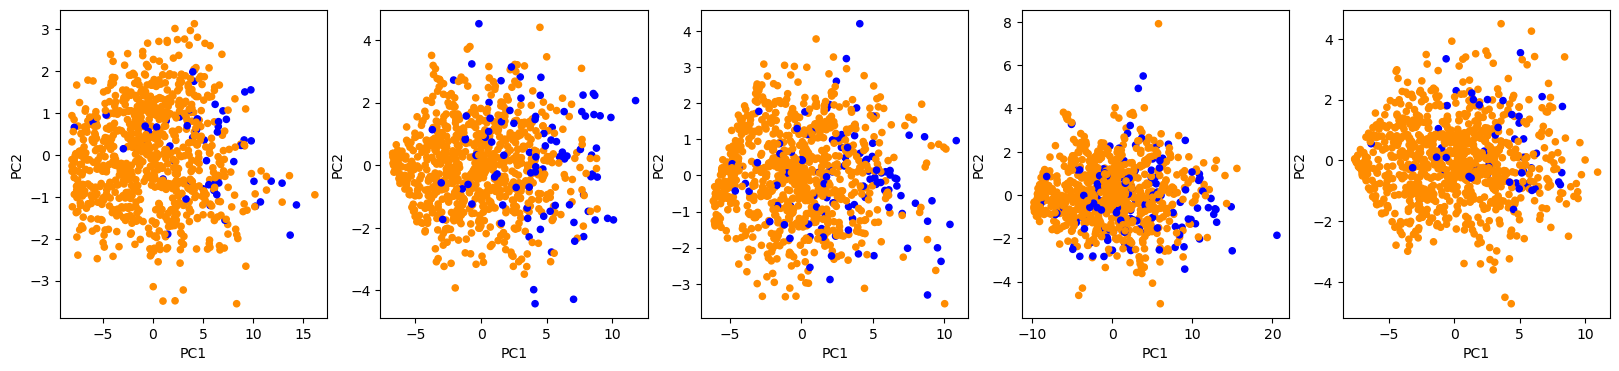

In [209]:
imputer = SimpleImputer()
pca = PCA()

fig, axs = plt.subplots(1,5, figsize=(20,4))

cmap = ListedColormap(["darkorange", "blue"])

for idx, unit in enumerate(random_series):
    feat_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    feat_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    imputer.fit(feat_train)
    X_val_imputed = imputer.transform(feat_val)
    transformed_data = pca.fit_transform(X_val_imputed)

    x_train = df_train.loc[df_train["series_id"]==unit, "target"].to_numpy()
    X = np.fft.fft(x_train, norm="ortho")
    freqs = np.fft.fftfreq(len(X))
    
    n_train = np.arange(len(x_train))
    x_recon = forecast_prior(df_val.loc[df_val["series_id"]==unit].index.to_numpy(), X, freqs, cutoff=15)

    res = df_val.loc[df_val["series_id"]==unit,'target']-x_recon
    is_spike = res > 7
    axs[idx].scatter(transformed_data[:,0], transformed_data[:,1], c=is_spike.to_numpy(), s=20, cmap=cmap)
    axs[idx].set_xlabel("PC1")
    axs[idx].set_ylabel("PC2")
plt.show()

Looks like some mild clustering. This could be an indicator that while the prior removes some obvious structure,  there is still some meaningful information to learn from the features since there is some separation depending on residual magnitude.

Let's also look at which features contribute the most to the principal components.

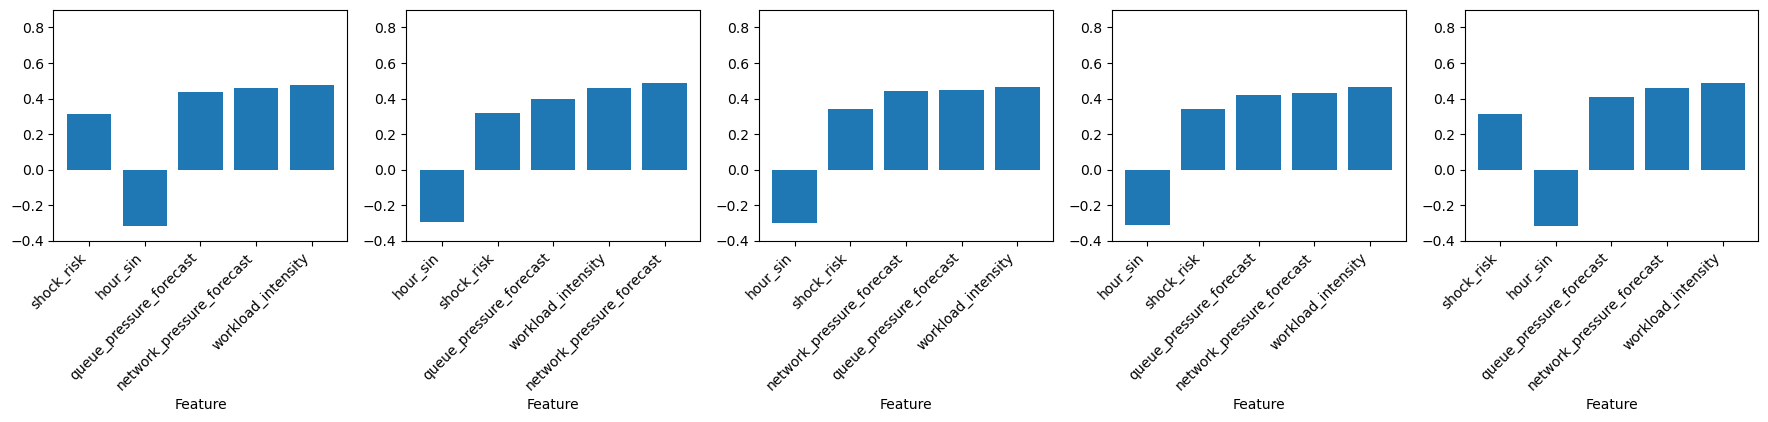

In [239]:
imputer = SimpleImputer()
pca = PCA()
scaler = StandardScaler()

fig, axs = plt.subplots(1,5, figsize=(22,3))

cmap = ListedColormap(["darkorange", "blue"])

for idx, unit in enumerate(random_series):
    feat_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    feat_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    imputer.fit(feat_train)
    scaler.fit(feat_train)
    X_val_imputed = imputer.transform(feat_val)
    X_val_imputed = pd.DataFrame(X_val_imputed, columns=feat_val.columns)
    X_val_imputed = scaler.transform(X_val_imputed)
    transformed_data = pca.fit_transform(X_val_imputed)

    cols = df_val.columns.to_numpy()[2:-1]
    sorting_idx = np.argsort(np.abs(pca.components_[0,:]))[-5:] 

    axs[idx].bar(np.arange(5), pca.components_[0,sorting_idx])
    axs[idx].set_xlabel("Feature")
    axs[idx].set_xticks(np.arange(5), cols[sorting_idx], ha="right", rotation=45)
    axs[idx].set_ylim(-0.4, 0.9)
plt.show()

So the features along which most of the variance lies are workload_intensity, queue_pressure_forecast and network_pressure_forecast. But are those also the features that are most predictive of the target/the residuals?

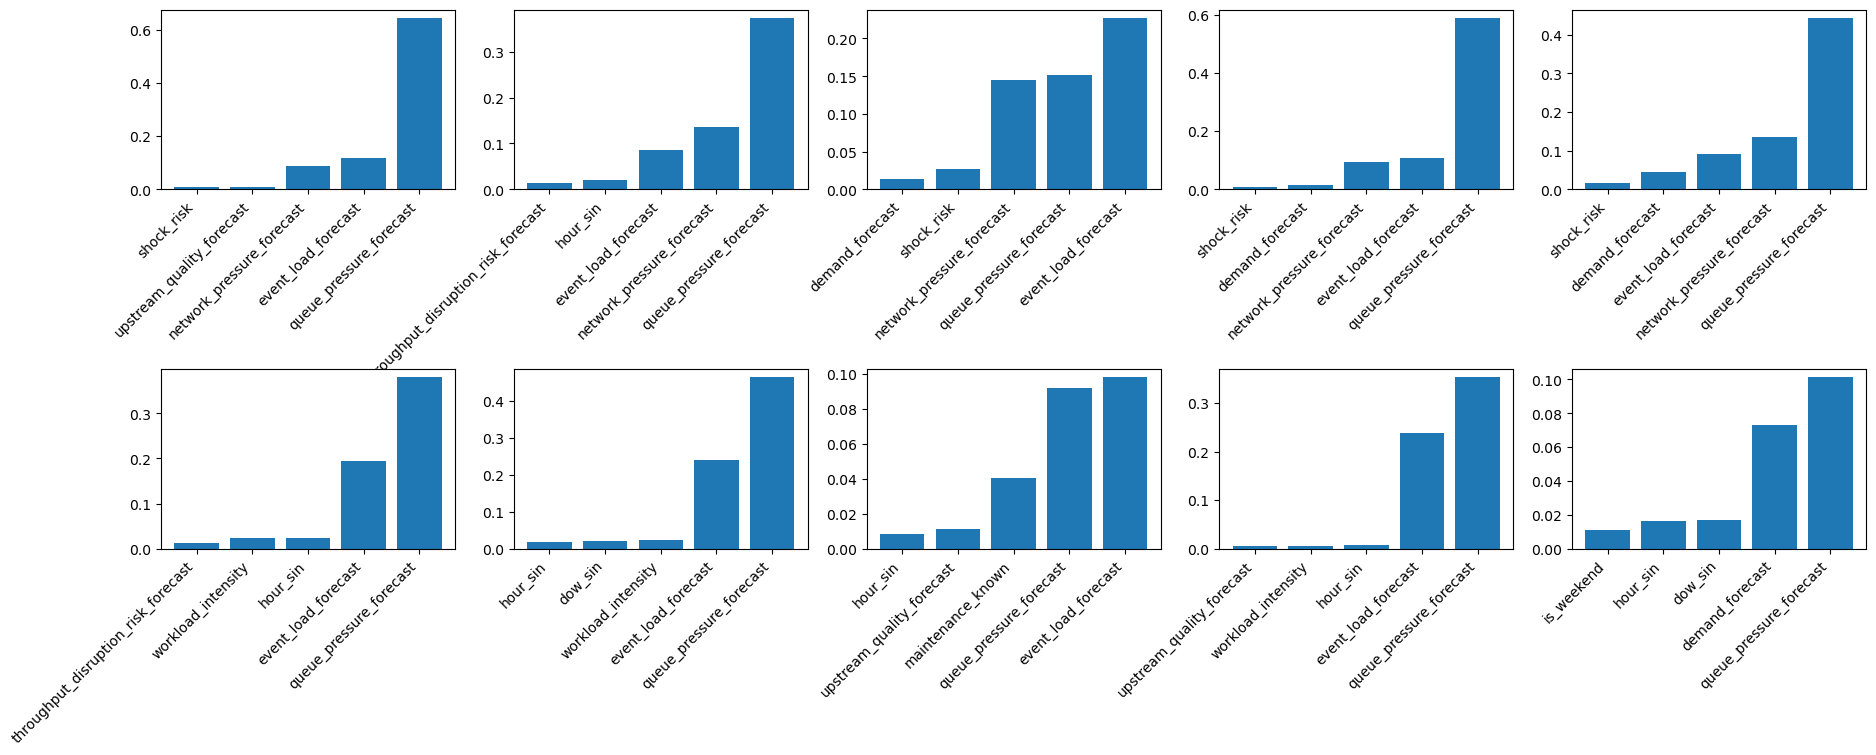

In [255]:
rfregressor = RandomForestRegressor()
imputer = SimpleImputer()
scaler = StandardScaler()

fig, axs = plt.subplots(2,5, figsize=(22,7))

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    y_train = df_train.loc[df_train["series_id"]==unit,"target"]
    x_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    y_val = df_val.loc[df_val["series_id"]==unit,"target"]
    times_val = y_val.index.to_numpy()
    times_train = y_train.index.to_numpy()

    cols = x_train.columns
    x_train=imputer.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = imputer.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    
    rfregressor.fit(x_train, y_train)

    perm = permutation_importance(rfregressor, x_val, y_val, n_repeats=10, random_state=0)
    importances = perm.importances_mean
    sorting_idx = np.argsort(importances)[-5:]
    sorting_idx = sorting_idx[-5:]

    axs[0,idx].bar(np.arange(5), importances[sorting_idx])
    axs[0,idx].set_xticks(np.arange(5), cols[sorting_idx])
    axs[0,idx].set_xticks(np.arange(5), cols[sorting_idx], ha="right", rotation=45)

    fig.subplots_adjust(hspace=1.0) 
    
    Y = np.fft.fft(y_train, norm="ortho")
    freqs = np.fft.fftfreq(len(Y))
    
    n_train = np.arange(len(x_train))
    y_recon = forecast_prior(times_val, Y, freqs, cutoff=15)
    y_recon_train = forecast_prior(times_train, Y, freqs, cutoff=15)

    res = y_val-y_recon
    res_train = y_train-y_recon_train

    rfregressor.fit(x_train, res_train)

    perm = permutation_importance(rfregressor, x_val, res, n_repeats=10, random_state=0)
    importances = perm.importances_mean
    sorting_idx = np.argsort(importances)[-5:]
    sorting_idx = sorting_idx[-5:]
 
    axs[1,idx].bar(np.arange(5), importances[sorting_idx])
    axs[1,idx].set_xticks(np.arange(5), cols[sorting_idx])
    axs[1, idx].set_xticks(np.arange(5), cols[sorting_idx], ha="right", rotation=45)


    

Event load forecast didn't show up in the PCA but is amongst the most predictive features for both the actual data and the residuals. However, using the prior seems to remove a lot of dependency on network pressure forecast.

Lets look at the cross-correlation of some of the highest scoring features with the raw target as well as the residual.

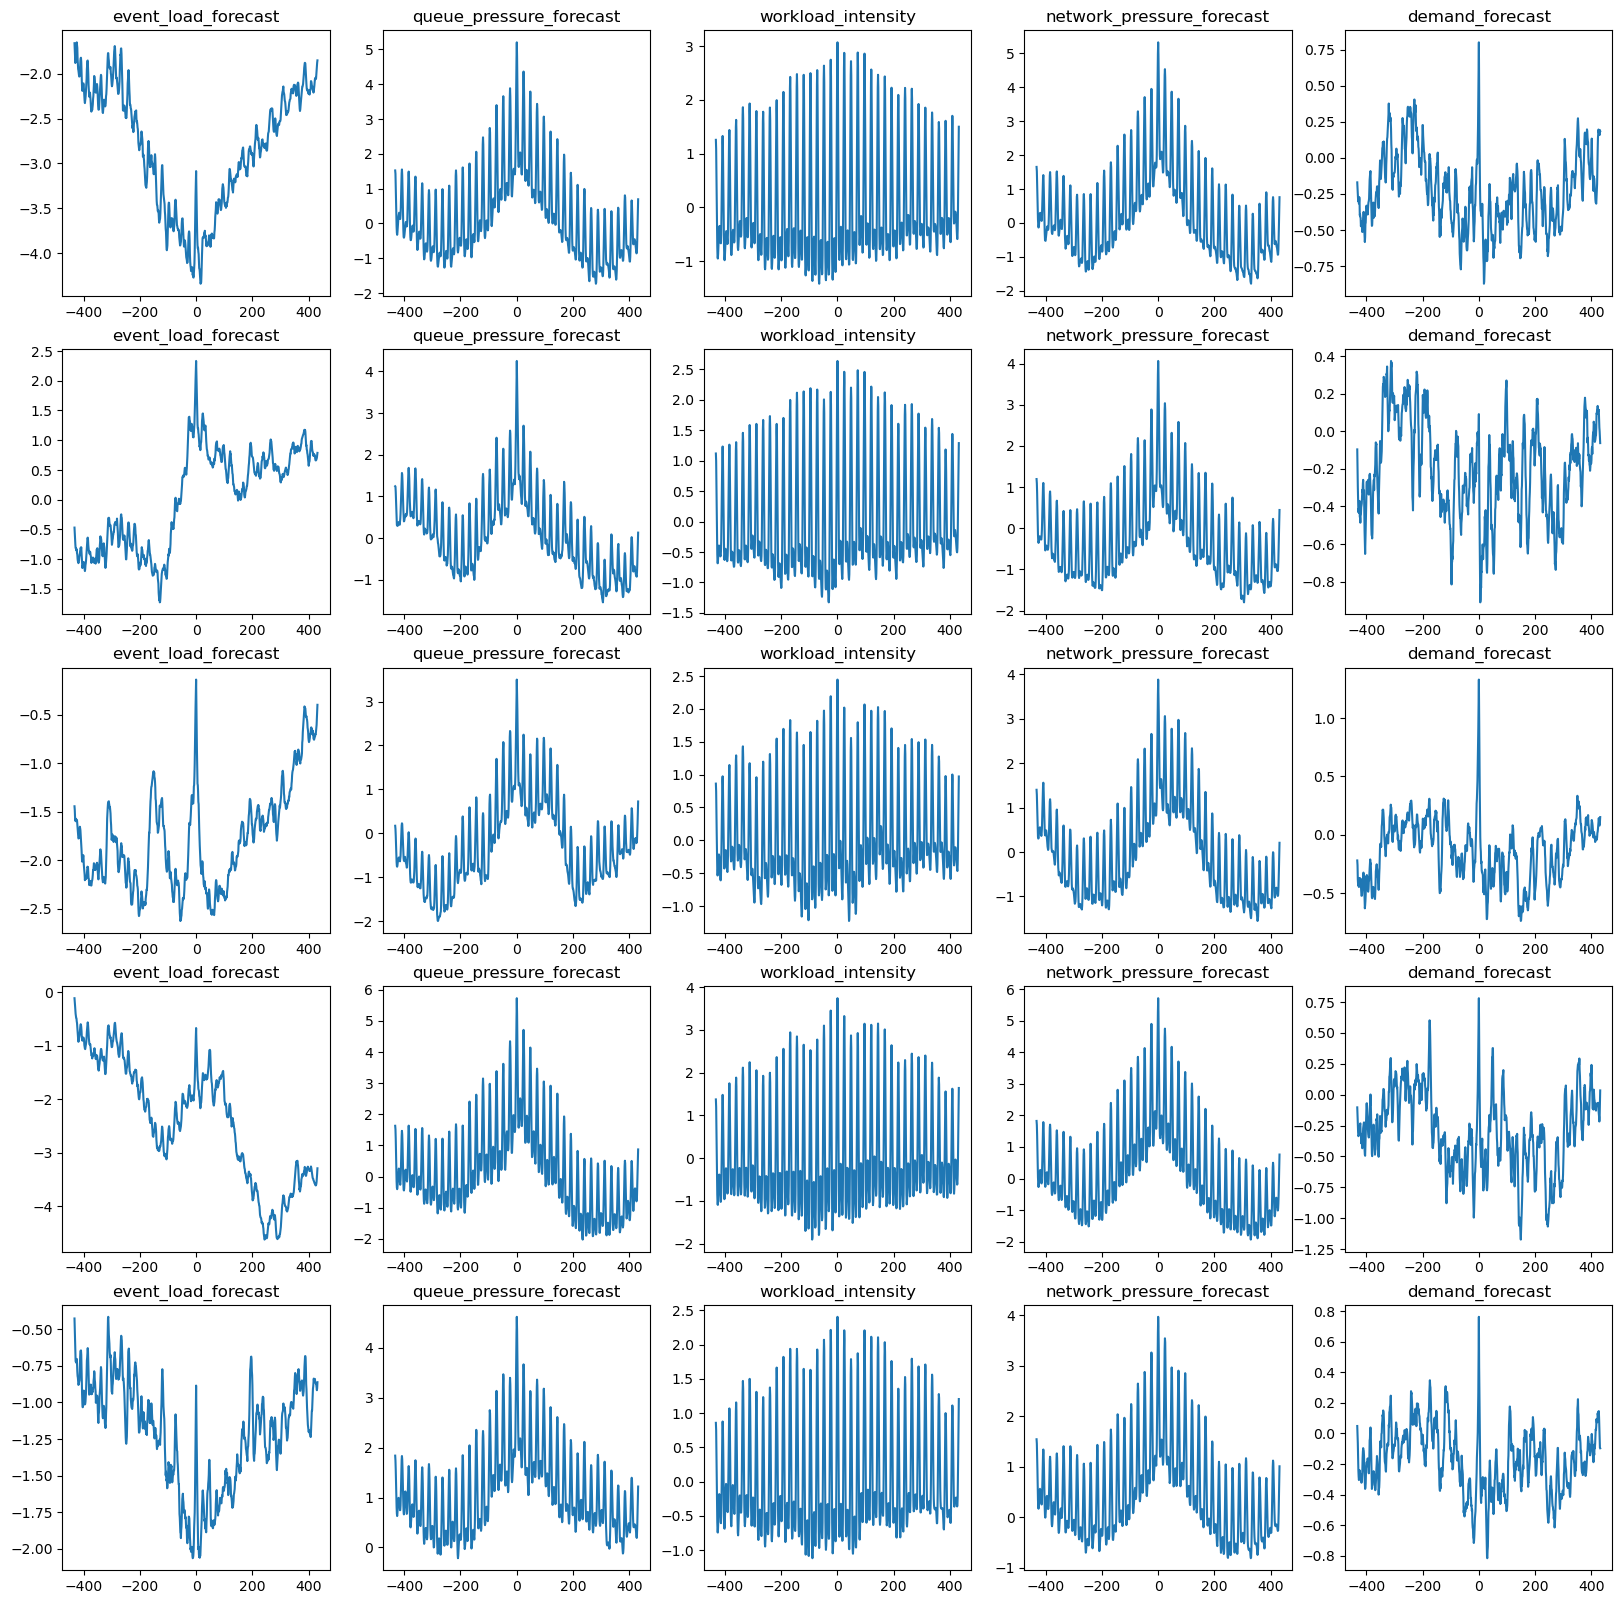

In [272]:
fig, axs = plt.subplots(5,5, figsize=(20,20))

selected_features = ["event_load_forecast", "queue_pressure_forecast", "workload_intensity", "network_pressure_forecast", "demand_forecast"]

imputer = SimpleImputer()
scaler = StandardScaler()

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    y_train = df_train.loc[df_train["series_id"]==unit,"target"]
    x_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    y_val = df_val.loc[df_val["series_id"]==unit,"target"]
    times_val = y_val.index.to_numpy()
    times_train = y_train.index.to_numpy()

    cols = x_train.columns
    x_train=imputer.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = imputer.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)

    
    lags = correlation_lags(len(x_val), len(y_val), mode="same")

    for idx_2, feat in enumerate(selected_features):
        corr = np.correlate(x_val.loc[:,feat], y_val, mode="same")
        axs[idx, idx_2].plot(lags, corr/len(corr))
        axs[idx, idx_2].set_title(feat)
        #axs[idx, idx_2].set_xlim(-500,1)
    

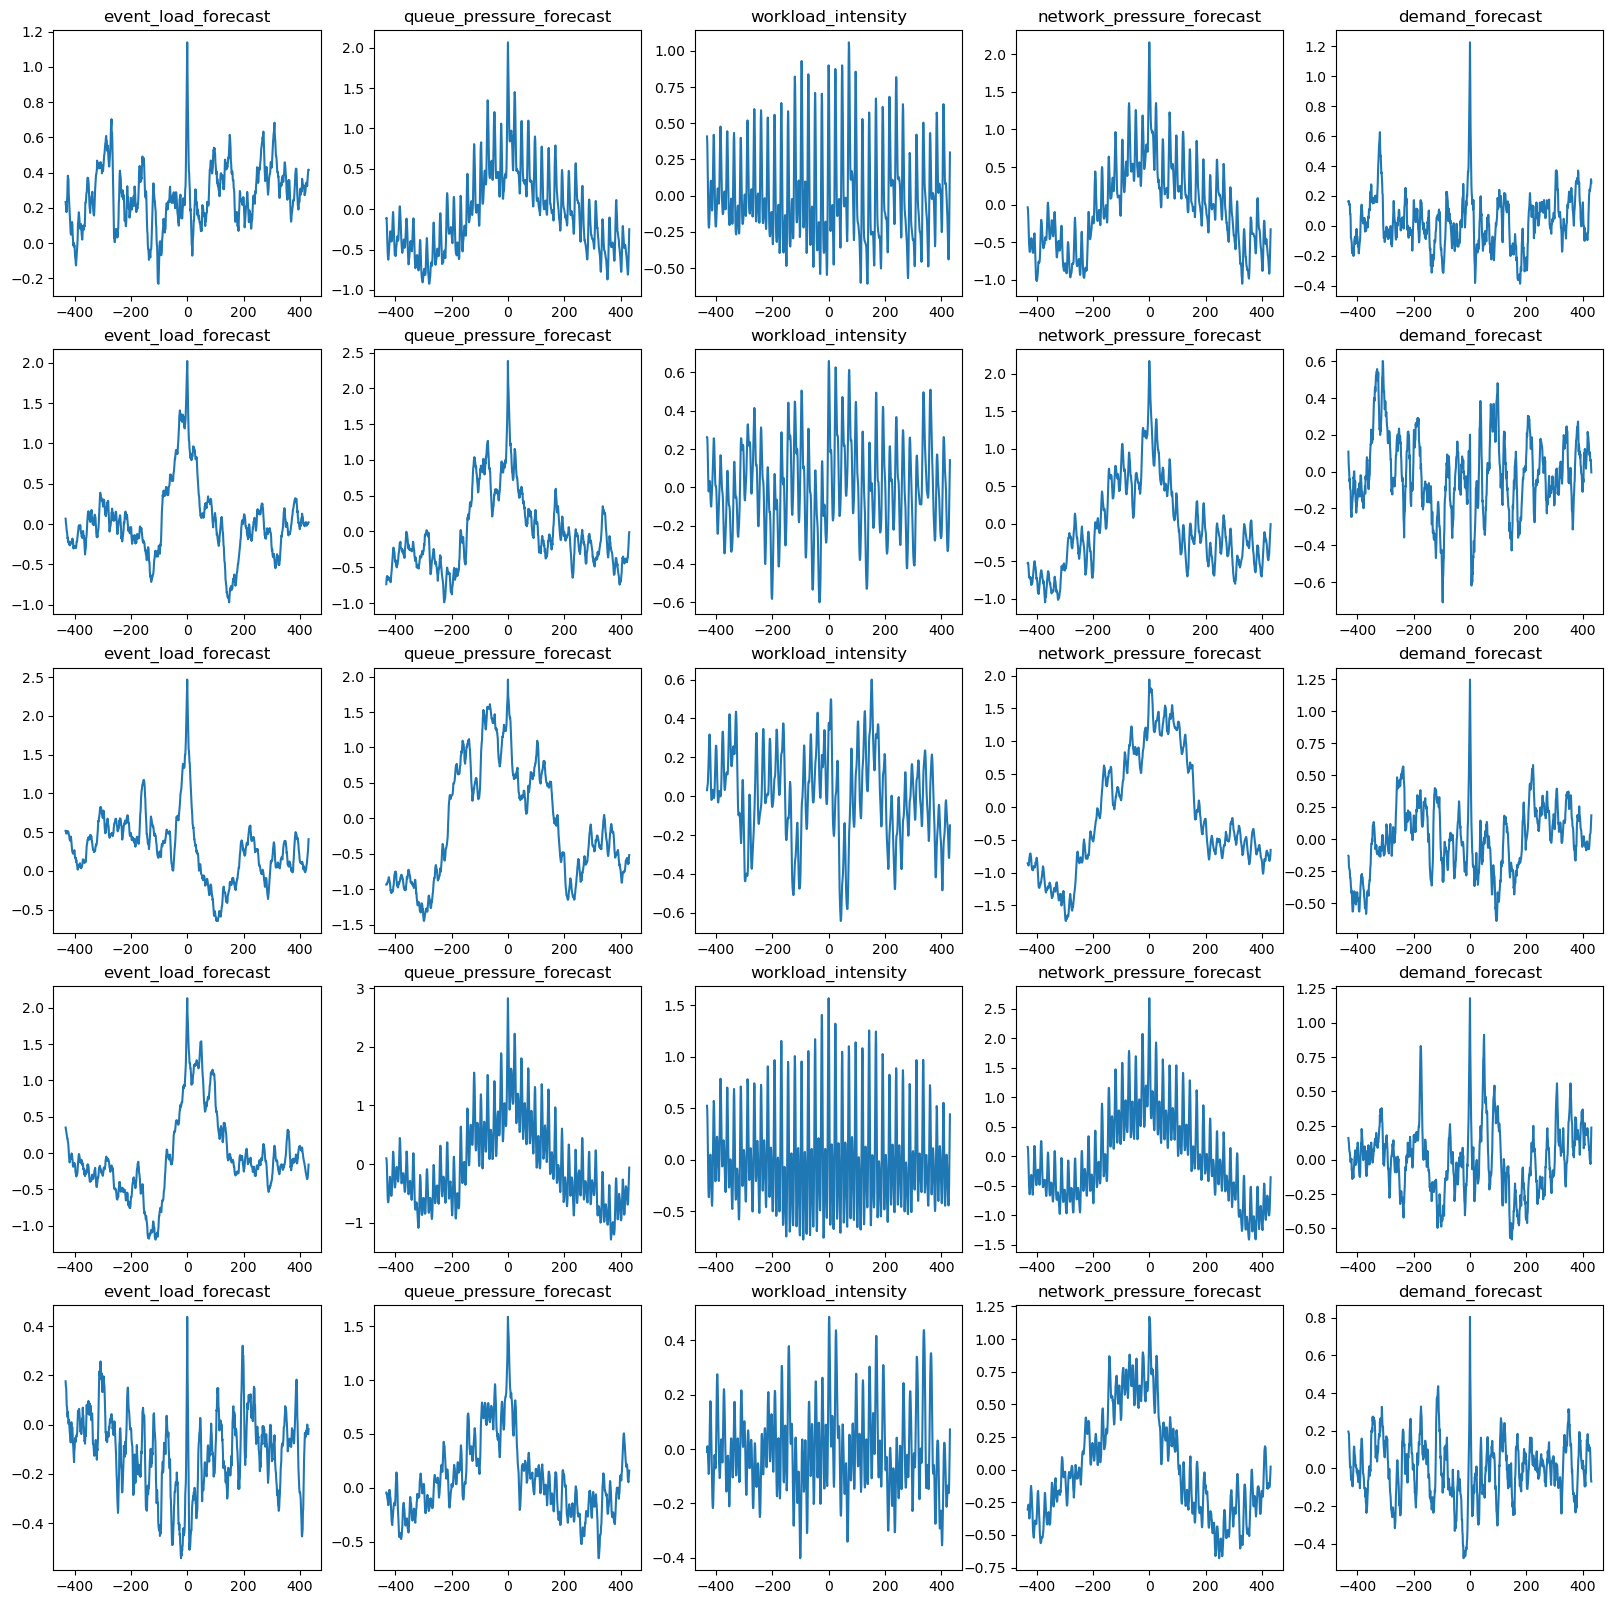

In [277]:
fig, axs = plt.subplots(5,5, figsize=(20,20))

selected_features = ["event_load_forecast", "queue_pressure_forecast", "workload_intensity", "network_pressure_forecast", "demand_forecast"]

imputer = SimpleImputer()
scaler = StandardScaler()

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    y_train = df_train.loc[df_train["series_id"]==unit,"target"]
    x_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    y_val = df_val.loc[df_val["series_id"]==unit,"target"]
    times_val = y_val.index.to_numpy()
    times_train = y_train.index.to_numpy()

    cols = x_train.columns
    x_train=imputer.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = imputer.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_train = scaler.fit_transform(x_train)
    x_train = pd.DataFrame(x_train,columns=cols)
    x_val = scaler.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_val = pd.DataFrame(x_val, columns=cols)

    
    Y = np.fft.fft(y_train, norm="ortho")
    freqs = np.fft.fftfreq(len(Y))
    
    n_train = np.arange(len(x_train))
    y_recon = forecast_prior(times_val, Y, freqs, cutoff=15)
    y_recon_train = forecast_prior(times_train, Y, freqs, cutoff=15)

    res = y_val-y_recon
    res_train = y_train-y_recon_train
    
    lags = correlation_lags(len(x_val), len(res), mode="same")

    for idx_2, feat in enumerate(selected_features):
        corr = np.correlate(x_val.loc[:,feat], res, mode="same")
        axs[idx, idx_2].plot(lags, corr/len(corr))
        axs[idx, idx_2].set_title(feat)
    

For the event load forecast, we see that the residuals have a much more similar correlation with the feature (shapewise) across series than the raw data. This is a good thing because it makes learning easier.

### ARIMA

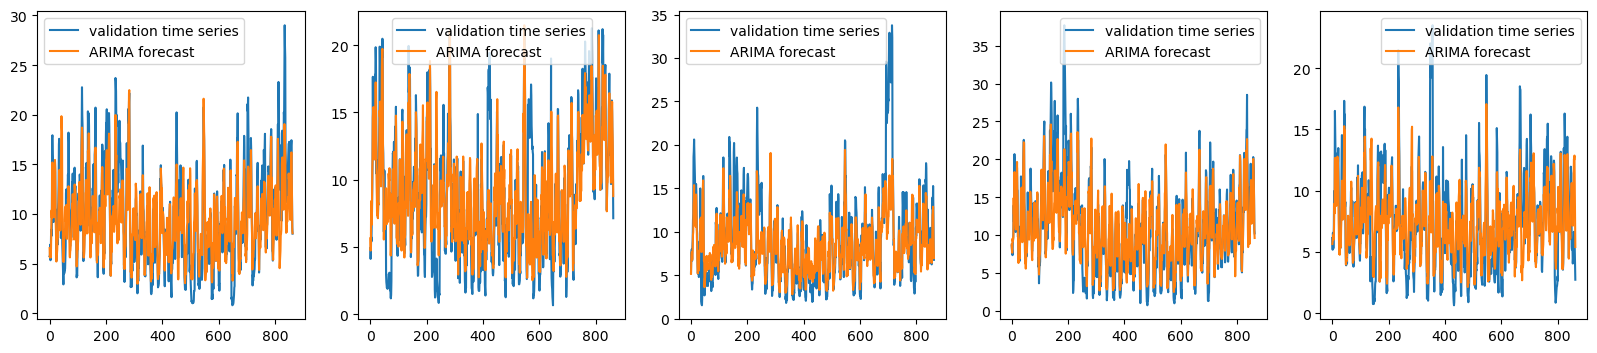

In [304]:
fig, axs = plt.subplots(1,5, figsize=(20,4))

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    x_train.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_train = df_train.loc[df_train["series_id"]==unit,"target"]
    x_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    x_val.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_val = df_val.loc[df_val["series_id"]==unit,"target"]
    times_val = y_val.index.to_numpy()
    times_train = y_train.index.to_numpy()

    cols = x_train.columns
    x_train=imputer.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = imputer.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    
    model = ARIMA(endog=y_train.to_numpy(), exog=x_train, order=(1, 0, 1), trend='c', seasonal_order=(1, 0, 1, 24))
    fit = model.fit(method='innovations_mle')
    fcast = fit.forecast(len(y_val), exog = x_val.to_numpy())
  
    axs[idx].plot(y_val.to_numpy(), label="validation time series")
    axs[idx].plot(fcast, label="ARIMA forecast")
    #axs[idx].set_xlim(0,200)
    axs[idx].legend()

Residual mean:  0.3371369938782744
Residual std:  2.7189300168506456
Residual mean:  -0.1549281838503066
Residual std:  2.84710203066399
Residual mean:  0.7024453854794006
Residual std:  3.165701357369512
Residual mean:  0.19860863621438277
Residual std:  3.16140223337509
Residual mean:  0.09527222796421903
Residual std:  2.522056495930519


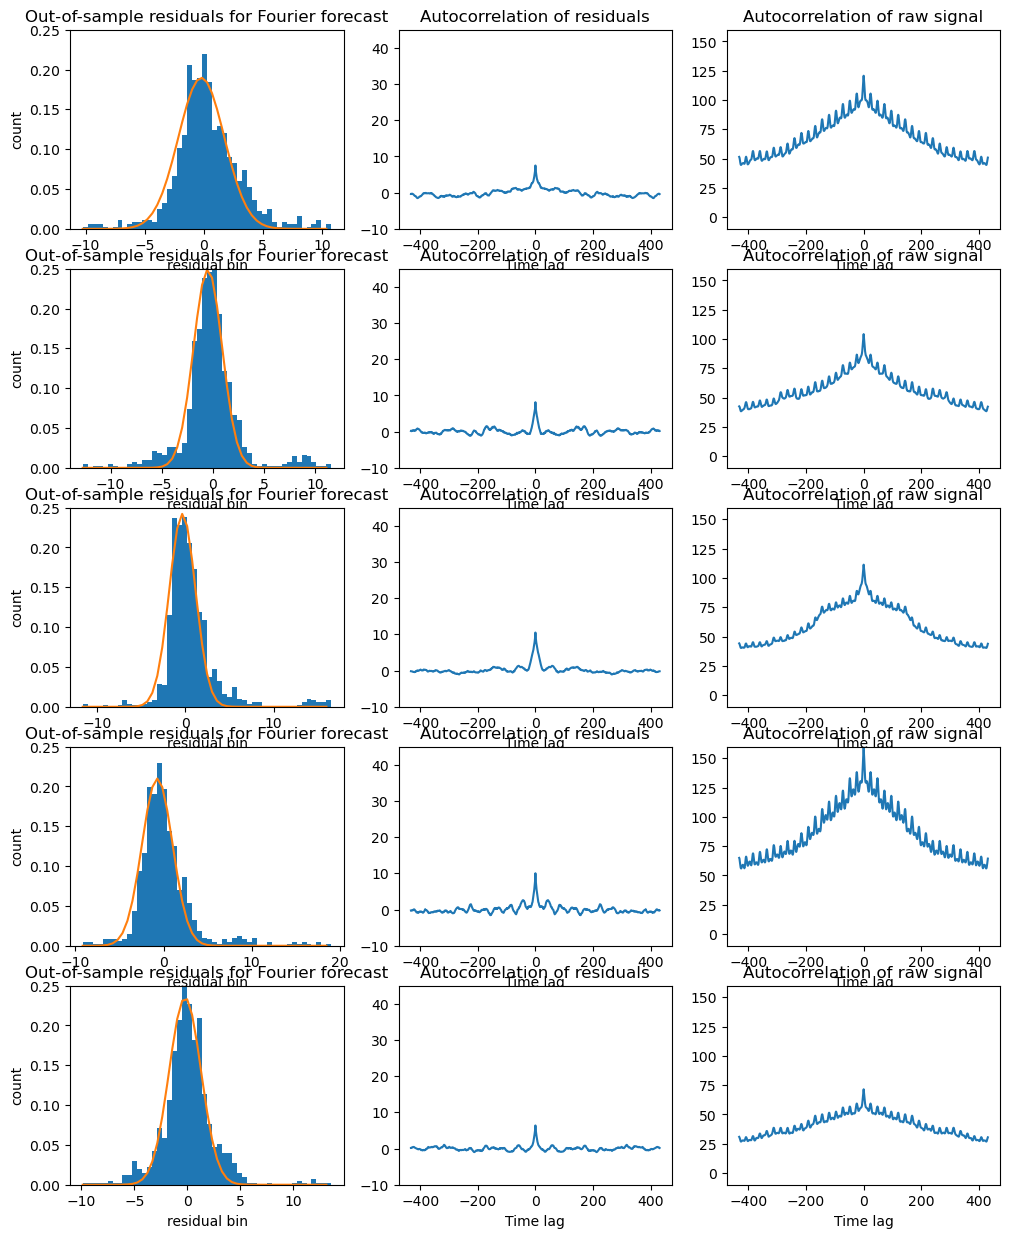

In [306]:
fig, axs = plt.subplots(5,3,figsize=(12,15))

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    x_train.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_train = df_train.loc[df_train["series_id"]==unit,"target"]
    x_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    x_val.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_val = df_val.loc[df_val["series_id"]==unit,"target"]
    times_val = y_val.index.to_numpy()
    times_train = y_train.index.to_numpy()

    cols = x_train.columns
    x_train=imputer.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = imputer.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    
    model = ARIMA(endog=y_train.to_numpy(), exog=x_train, order=(1, 0, 1), trend='c', seasonal_order=(1, 0, 1, 24))
    fit = model.fit(method='innovations_mle')
    fcast = fit.forecast(len(y_val), exog = x_val.to_numpy())
    res = y_val.to_numpy() - fcast
    res_hist, bin_edges = np.histogram(res, bins=50, density=True)

    gauss_fit = curve_fit(gaussian, bin_edges[:-1], res_hist, p0=[0.15,-3,8])
    fitted_gauss = gaussian(bin_edges[:-1], gauss_fit[0][0], gauss_fit[0][1], gauss_fit[0][2])
    res_corr = np.correlate(res, res, mode="same")
    lags = correlation_lags(len(res), len(res), mode="same")

    orig_corr = np.correlate(y_val.to_numpy(), y_val.to_numpy(),mode="same")

    axs[idx,0].hist(res, bin_edges, density=True)
    axs[idx,0].plot(bin_edges[:-1],fitted_gauss, label="gaussian fit")
    axs[idx,0].set_ylim(0,0.25)
    axs[idx,0].set_title("Out-of-sample residuals for Fourier forecast")
    axs[idx,0].set_xlabel("residual bin")
    axs[idx,0].set_ylabel("count")
    
    axs[idx,1].plot(lags, res_corr/len(res_corr))
    axs[idx,1].set_title("Autocorrelation of residuals")
    axs[idx,1].set_xlabel("Time lag")
    axs[idx,1].set_ylim(-10,45)

    axs[idx,2].plot(lags, orig_corr/len(orig_corr))
    axs[idx,2].set_title("Autocorrelation of raw signal")
    axs[idx,2].set_xlabel("Time lag")
    axs[idx,2].set_ylim(-10,160)
    
    print("Residual mean: ", np.mean(res))
    print("Residual std: ", np.std(res, ddof=1)) 
    
plt.show()
    

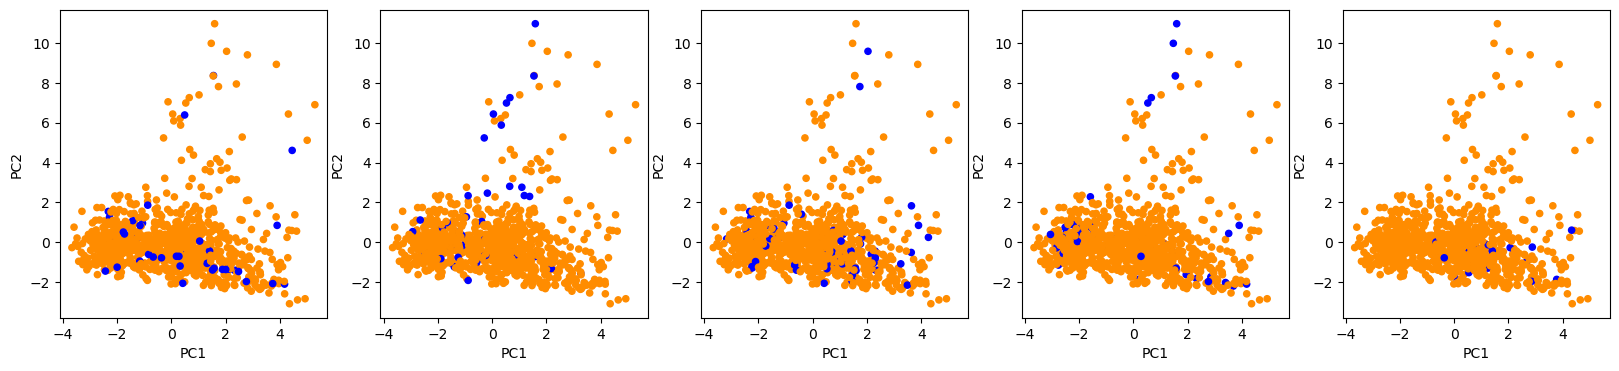

In [309]:
imputer = SimpleImputer()
pca = PCA()

fig, axs = plt.subplots(1,5, figsize=(20,4))

cmap = ListedColormap(["darkorange", "blue"])

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    x_train.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_train = df_train.loc[df_train["series_id"]==unit,"target"]
    x_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    x_val.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_val = df_val.loc[df_val["series_id"]==unit,"target"]
    times_val = y_val.index.to_numpy()
    times_train = y_train.index.to_numpy()

    cols = x_train.columns
    x_train=imputer.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = imputer.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    
    model = ARIMA(endog=y_train.to_numpy(), exog=x_train, order=(1, 0, 1), trend='c', seasonal_order=(1, 0, 1, 24))
    fit = model.fit(method='innovations_mle')
    fcast = fit.forecast(len(y_val), exog = x_val.to_numpy())
    res = y_val.to_numpy() - fcast
    is_spike = res > 5
    axs[idx].scatter(transformed_data[:,0], transformed_data[:,1], c=is_spike, s=20, cmap=cmap)
    axs[idx].set_xlabel("PC1")
    axs[idx].set_ylabel("PC2")
plt.show()

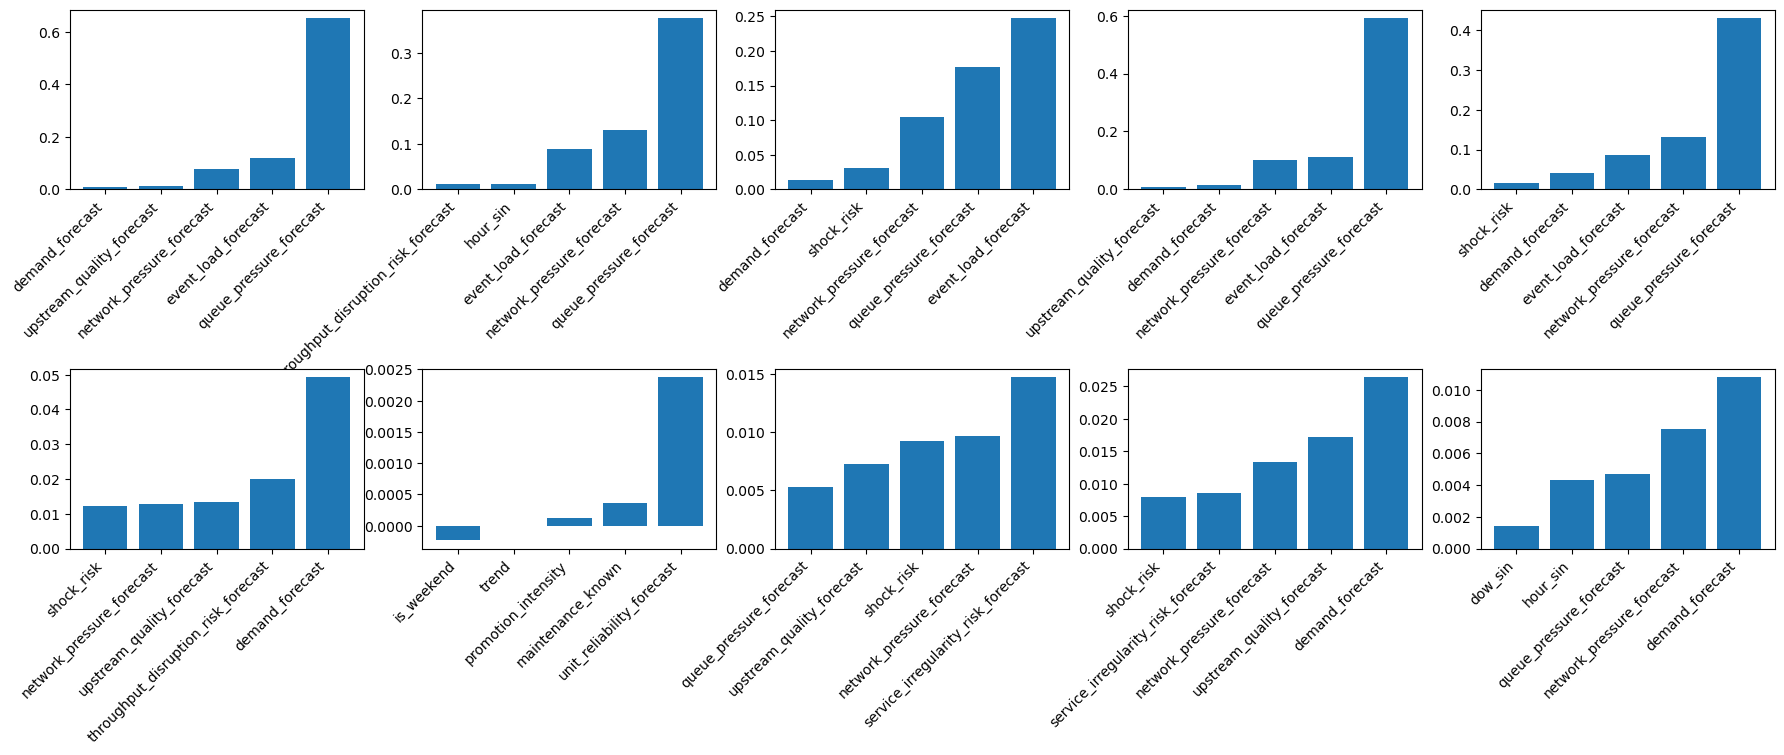

In [312]:
rfregressor = RandomForestRegressor()
imputer = SimpleImputer()
scaler = StandardScaler()

fig, axs = plt.subplots(2,5, figsize=(22,7))

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    x_train.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_train = df_train.loc[df_train["series_id"]==unit,"target"]
    x_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    x_val.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_val = df_val.loc[df_val["series_id"]==unit,"target"]
    times_val = y_val.index.to_numpy()
    times_train = y_train.index.to_numpy()

    cols = x_train.columns
    x_train=imputer.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = imputer.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_train = scaler.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = scaler.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    
    model = ARIMA(endog=y_train.to_numpy(), exog=x_train, order=(1, 0, 1), trend='c', seasonal_order=(1, 0, 1, 24))
    fit = model.fit(method='innovations_mle')
    fcast = fit.forecast(len(y_val), exog = x_val.to_numpy())
    
    rfregressor.fit(x_train, y_train)

    perm = permutation_importance(rfregressor, x_val, y_val, n_repeats=10, random_state=0)
    importances = perm.importances_mean
    sorting_idx = np.argsort(importances)[-5:]
    sorting_idx = sorting_idx[-5:]

    axs[0,idx].bar(np.arange(5), importances[sorting_idx])
    axs[0,idx].set_xticks(np.arange(5), cols[sorting_idx])
    axs[0,idx].set_xticks(np.arange(5), cols[sorting_idx], ha="right", rotation=45)

    fig.subplots_adjust(hspace=1.0) 
    
    model = ARIMA(endog=y_train.to_numpy(), exog=x_train, order=(1, 0, 1), trend='c', seasonal_order=(1, 0, 1, 24))
    fit = model.fit(method='innovations_mle')
    fcast = fit.forecast(len(y_val), exog = x_val.to_numpy())
    res = y_val.to_numpy() - fcast

    res_train = y_train.to_numpy()-fit.fittedvalues

    rfregressor.fit(x_train, res_train)

    perm = permutation_importance(rfregressor, x_val, res, n_repeats=10, random_state=0)
    importances = perm.importances_mean
    sorting_idx = np.argsort(importances)[-5:]
    sorting_idx = sorting_idx[-5:]
 
    axs[1,idx].bar(np.arange(5), importances[sorting_idx])
    axs[1,idx].set_xticks(np.arange(5), cols[sorting_idx])
    axs[1, idx].set_xticks(np.arange(5), cols[sorting_idx], ha="right", rotation=45)
    

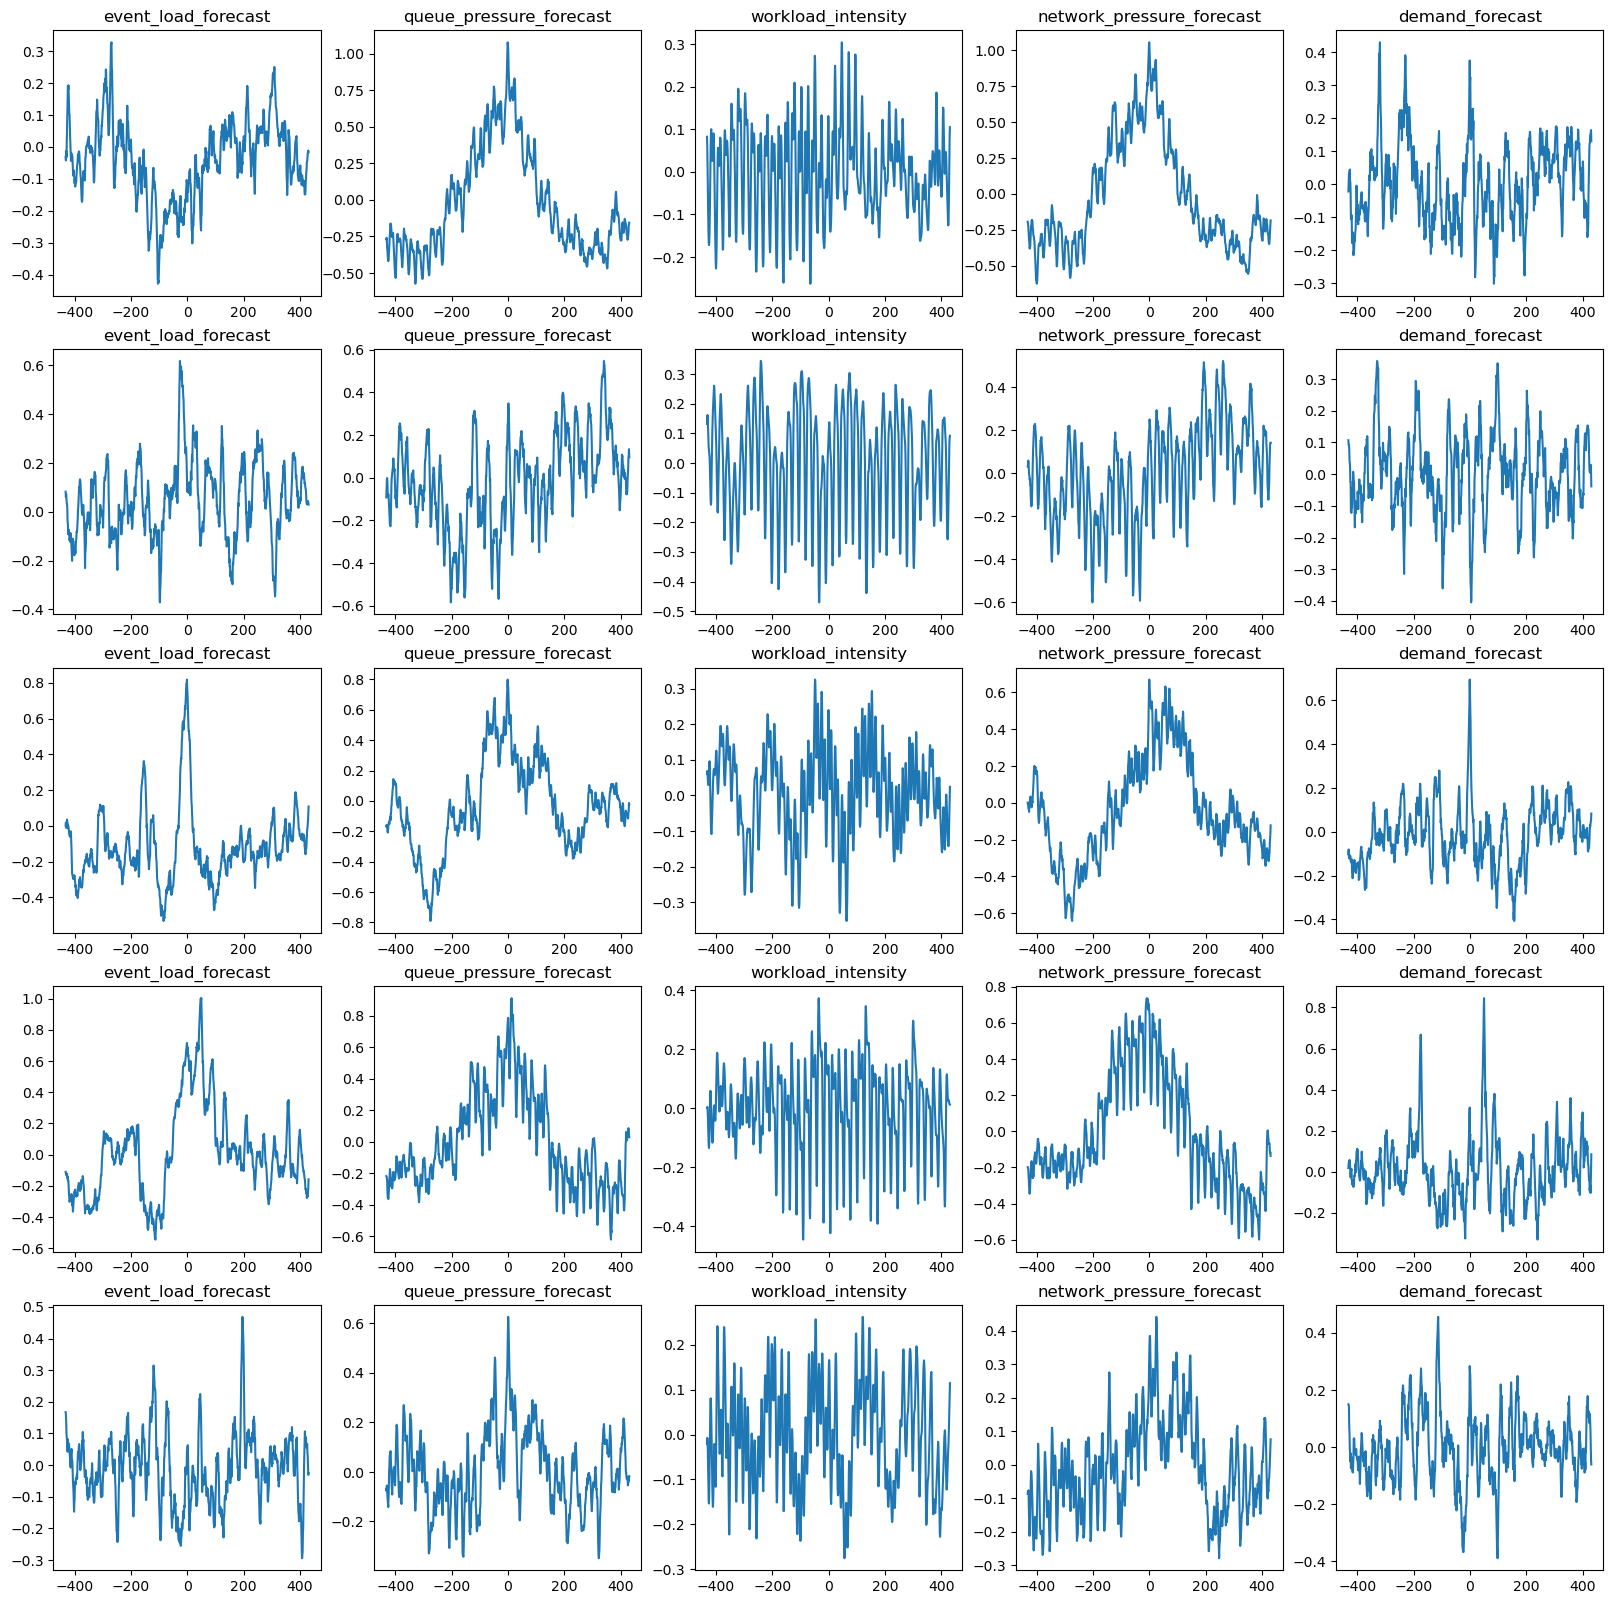

In [314]:
fig, axs = plt.subplots(5,5, figsize=(20,20))

selected_features = ["event_load_forecast", "queue_pressure_forecast", "workload_intensity", "network_pressure_forecast", "demand_forecast"]

imputer = SimpleImputer()
scaler = StandardScaler()

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    x_train.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_train = df_train.loc[df_train["series_id"]==unit,"target"]
    x_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    x_val.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_val = df_val.loc[df_val["series_id"]==unit,"target"]
    times_val = y_val.index.to_numpy()
    times_train = y_train.index.to_numpy()

    cols = x_train.columns
    x_train=imputer.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = imputer.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    
    model = ARIMA(endog=y_train.to_numpy(), exog=x_train, order=(1, 0, 1), trend='c', seasonal_order=(1, 0, 1, 24))
    fit = model.fit(method='innovations_mle')
    fcast = fit.forecast(len(y_val), exog = x_val.to_numpy())
    res = y_val.to_numpy() - fcast
    
    lags = correlation_lags(len(x_val), len(res), mode="same")

    for idx_2, feat in enumerate(selected_features):
        corr = np.correlate(x_val.loc[:,feat], res, mode="same")
        axs[idx, idx_2].plot(lags, corr/len(corr))
        axs[idx, idx_2].set_title(feat)
    

## Check if hidden markov model/state-switching model might be justified

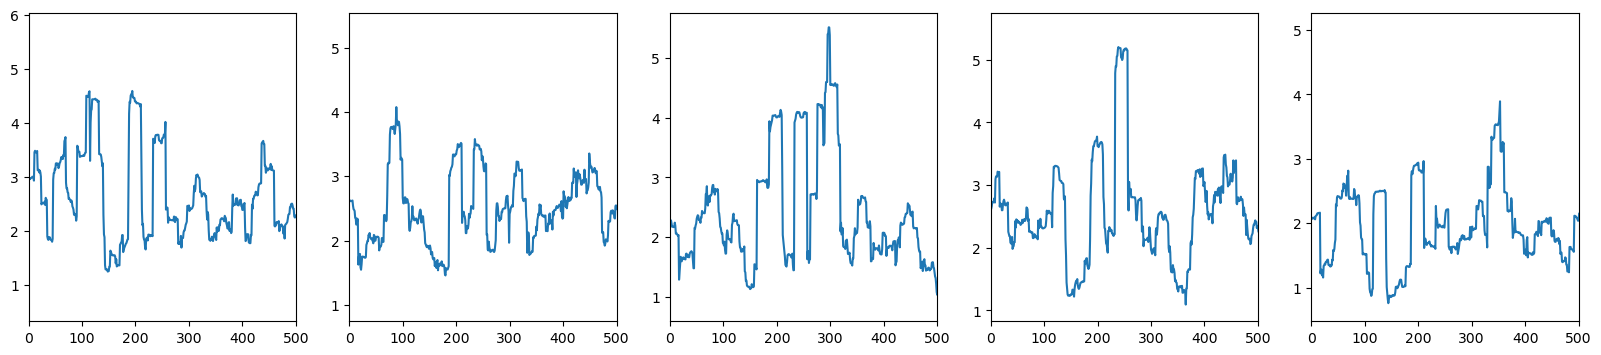

In [382]:
from numpy.lib.stride_tricks import sliding_window_view

fig, axs = plt.subplots(1,5, figsize=(20,4))

for idx, unit in enumerate(random_series):
    log_target = np.diff(df_train.loc[df_train["series_id"]==unit,"target"])
    window = 24
    windows = sliding_window_view(log_target, window_shape=window)
    rolling_vol = np.std(windows, axis=1, ddof=1)  
    axs[idx].plot(rolling_vol)
    axs[idx].set_xlim(0,500)

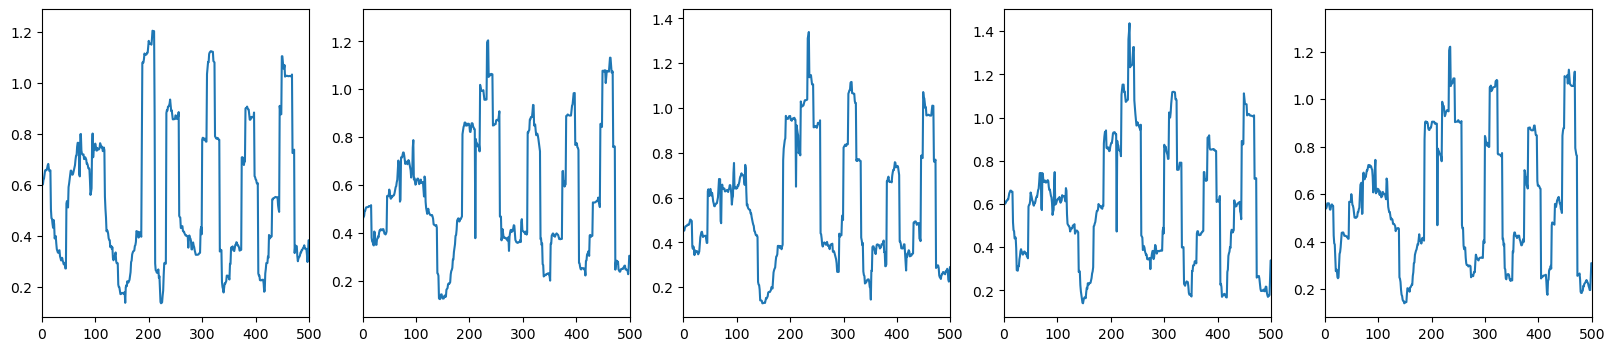

In [383]:
fig, axs = plt.subplots(1,5, figsize=(20,4))

for idx, unit in enumerate(random_series):
    log_target = np.diff(df_train.loc[df_train["series_id"]==unit,'event_load_forecast'].to_numpy())
    window = 24
    windows = sliding_window_view(log_target, window_shape=window)
    rolling_vol = np.nanstd(windows, axis=1, ddof=1)  
    axs[idx].plot(rolling_vol)
    axs[idx].set_xlim(0,500)

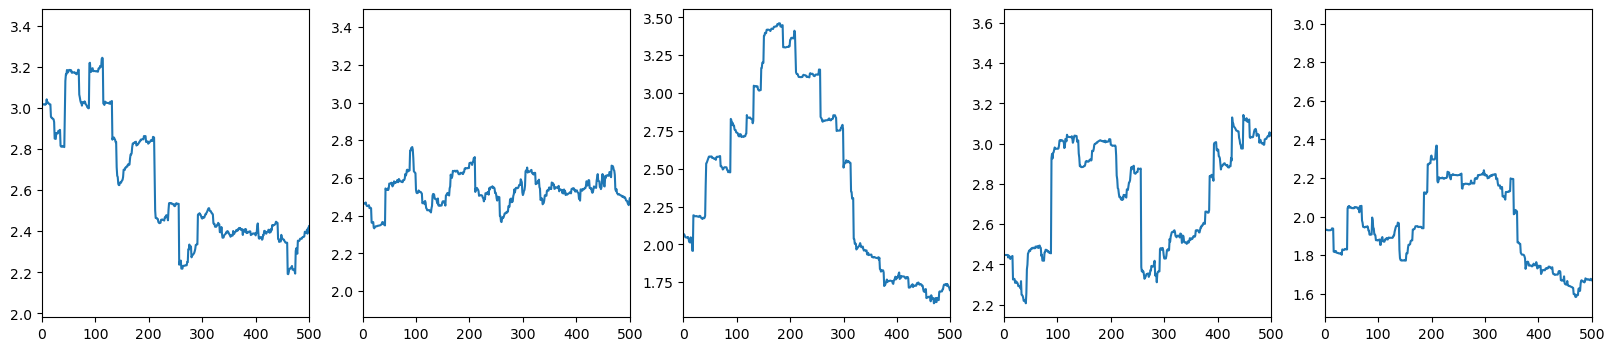

In [384]:
from numpy.lib.stride_tricks import sliding_window_view

fig, axs = plt.subplots(1,5, figsize=(20,4))

for idx, unit in enumerate(random_series):
    log_target = np.diff(df_train.loc[df_train["series_id"]==unit,"target"])
    window = 24*7
    windows = sliding_window_view(log_target, window_shape=window)
    rolling_vol = np.std(windows, axis=1, ddof=1)  
    axs[idx].plot(rolling_vol)
    axs[idx].set_xlim(0,500)

Let's also try on the ARIMA residuals from earlier.

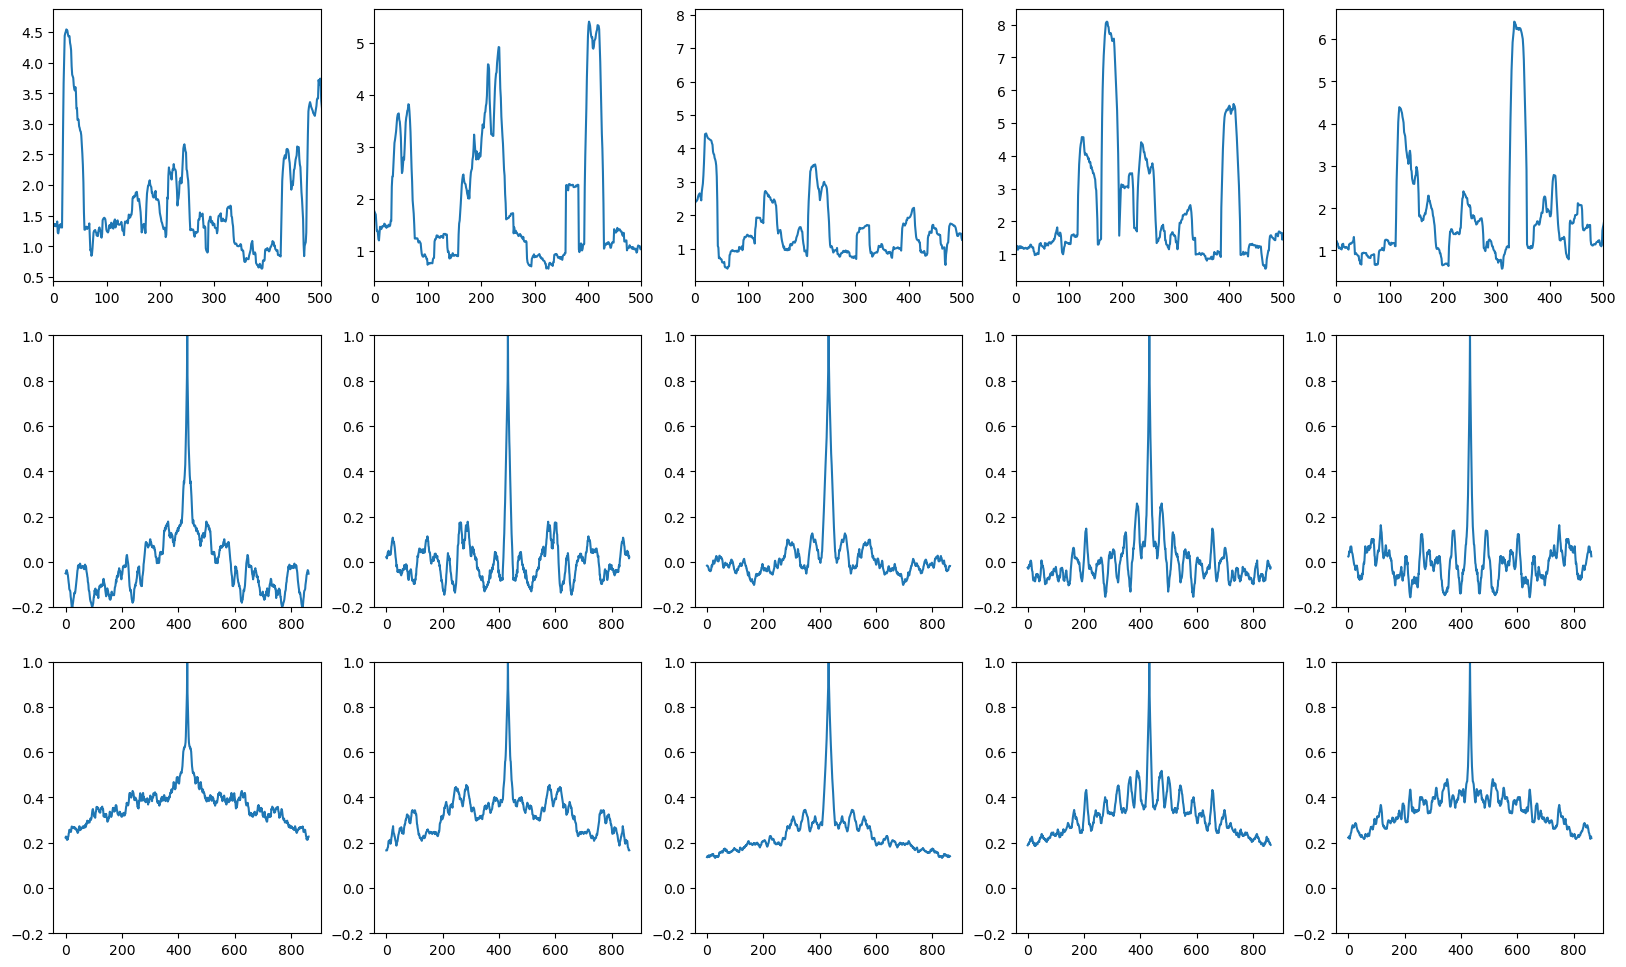

In [394]:
fig, axs = plt.subplots(3,5,figsize=(20,12))

for idx, unit in enumerate(random_series):
    x_train = df_train.loc[df_train["series_id"]==unit,:].iloc[:,2:-1]
    x_train.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_train = df_train.loc[df_train["series_id"]==unit,"target"]
    x_val = df_val.loc[df_val["series_id"]==unit,:].iloc[:,2:-1]
    x_val.drop(["nominal_capacity", "zone_sin", "zone_cos"], axis=1, inplace=True)
    y_val = df_val.loc[df_val["series_id"]==unit,"target"]
    times_val = y_val.index.to_numpy()
    times_train = y_train.index.to_numpy()

    cols = x_train.columns
    x_train=imputer.fit_transform(x_train)
    x_train = pd.DataFrame(x_train, columns=cols)
    x_val = imputer.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_val = pd.DataFrame(x_val, columns=cols)
    
    model = ARIMA(endog=y_train.to_numpy(), exog=x_train, order=(1, 0, 1), trend='c', seasonal_order=(1, 0, 1, 24))
    fit = model.fit(method='innovations_mle')
    fcast = fit.forecast(len(y_val), exog = x_val.to_numpy())
    res = y_val.to_numpy() - fcast

    res_abs_corr = np.correlate(np.abs(res), np.abs(res), mode="same")
    res_corr = np.correlate(res, res, mode="same")
    lags = correlation_lags(len(res), len(res), mode="same")

    window = 24
    windows = sliding_window_view(res, window_shape=window)
    rolling_vol = np.std(windows, axis=1, ddof=1)  
    axs[0,idx].plot(rolling_vol)
    axs[0,idx].set_xlim(0,500)

    axs[1,idx].plot(res_corr/np.max(res_corr))
    axs[1,idx].set_ylim(-0.2,1)
    axs[2,idx].plot(res_abs_corr/np.max(res_abs_corr))
    axs[2,idx].set_ylim(-0.2,1)
    
plt.show()
    

Might be evidence of some volatility clustering.

## Discarded

Let's try a similar thing using Gaussian Process Regression. Because GP is inefficient, we are going to estimate the residual distribution by fitting GP regression in chunks and averaging the residuals.

In [190]:
imputer = SimpleImputer()
X_imputed = imputer.fit_transform(df_train.iloc[:,2:-1])

In [212]:
kern = 20*RBF()+ExpSineSquared(length_scale=1.0, periodicity=20.0)
gp_regressor = GaussianProcessRegressor(kernel=kern, alpha=100)

In [213]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_new_scaled= scaler.fit_transform(X=X_imputed)

In [214]:
#preds = np.zeros((10, len(df_val["target"])))
X_val = df_val.iloc[:,2:-1]
X_val = imputer.transform(X_val)
X_val = scaler.transform(X_val)
gp_regressor.fit(X_new_scaled[0:1000,:], df_train.iloc[0:1000,-1])
pred = gp_regressor.predict(X_val)
#for i in range(1,11):
    #gp_regressor.fit(X_new_scaled[int((i-1)*1000):int(i*1000),:], df_train.iloc[int((i-1)*1000):int(i*1000),-1])
    #preds[i-1,:]=gp_regressor.predict(X_val)
    #if i % 10 == 0:
        #print(i)

In [215]:
#residuals = preds - df_val["target"].to_numpy()[np.newaxis,:]
residuals = pred - df_val["target"].to_numpy()

In [216]:
print(np.mean(residuals))

-1.488074764761401


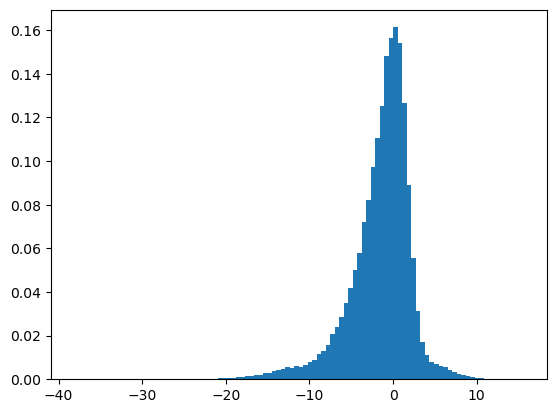

In [217]:
#plt.hist(np.mean(residuals, axis=0), bins=200, density=True)
plt.hist(residuals, bins=100, density=True)
plt.show()

In [218]:
res_corr = np.correlate(residuals, residuals, mode="same")

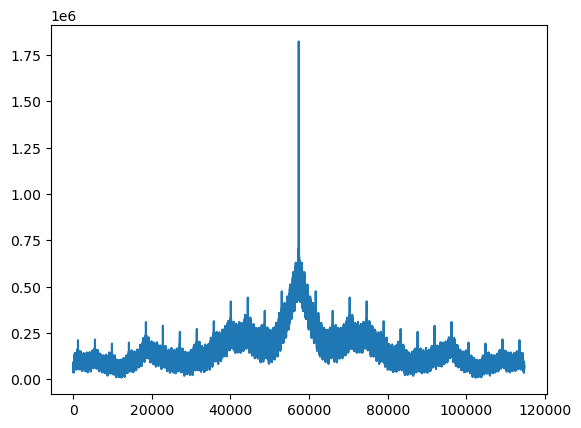

In [219]:
plt.plot(res_corr)

(3000.0, 4000.0)

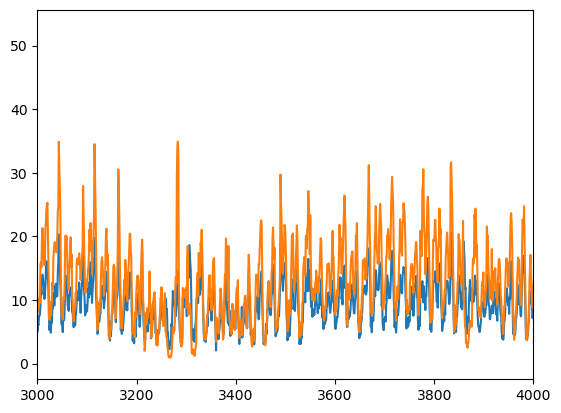

In [224]:
plt.plot(pred)
plt.plot(df_val["target"].to_numpy())
plt.xlim(3000,4000)

The GP regression seems a close fit overall, but it might be too aggressive and not leave enough for the neural network to learn. Furthermore it is harder to fit and the residuals look less normal. However, the autocorrelation of the residuals look like GP regression captures more of the remporally recurring structure compared to the fourier reconstruction.

Let's try a third method: ARIMA

Let's fit a model with interaction on the residuals

$r_t \sim \text{features}+\text{features}\times \text{sin} + \text{features}\times \text{cos}$

In [258]:
freqs_to_fit = np.array([1/24])

train_times = np.arange(290000, 300000)
test_times = np.arange(300000, len(df))

Xtr = X_train_imputed[290000:300000, :]
ytr = res_train#[290000:300000]
Xv = X_val_imputed

sin_mat = np.sin(2*np.pi*np.outer(train_times, freqs_to_fit))
cos_mat = np.cos(2*np.pi*np.outer(train_times, freqs_to_fit))
harm_mat = np.hstack([sin_mat, cos_mat])

interactions = [Xtr * harm_mat[:, j][:, None] for j in range(harm_mat.shape[1])]
Xtr_int = np.hstack(interactions)

X_train_full = np.hstack([Xtr, harm_mat, Xtr_int])

sin_mat_val = np.sin(2*np.pi*np.outer(test_times, freqs_to_fit))
cos_mat_val = np.cos(2*np.pi*np.outer(test_times, freqs_to_fit))
harm_mat_val = np.hstack([sin_mat_val, cos_mat_val])

interactions_val = [Xv * harm_mat_val[:, j][:, None] for j in range(harm_mat_val.shape[1])]
Xv_int = np.hstack(interactions_val)

X_val_full = np.hstack([Xv, harm_mat_val, Xv_int])

#model = Ridge(alpha=10)
model = LinearRegression()
model.fit(X_train_full, ytr)

new_forecast = model.predict(X_val_full)+fcast

(0.0, 1000.0)

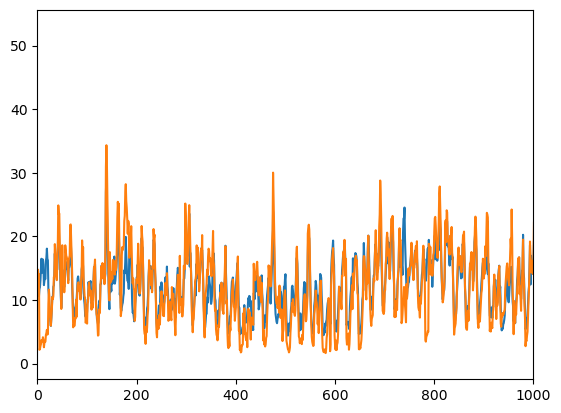

In [259]:
plt.plot(new_forecast.to_numpy())
plt.plot(df_val["target"].to_numpy())
plt.xlim(0,1000)

In [260]:
new_res = df_val["target"].to_numpy()-new_forecast 

In [261]:
print(np.sum(res**2)-np.sum(new_res**2))

42344.66075598542


The interaction with this specific frequency added does indead recude RSS

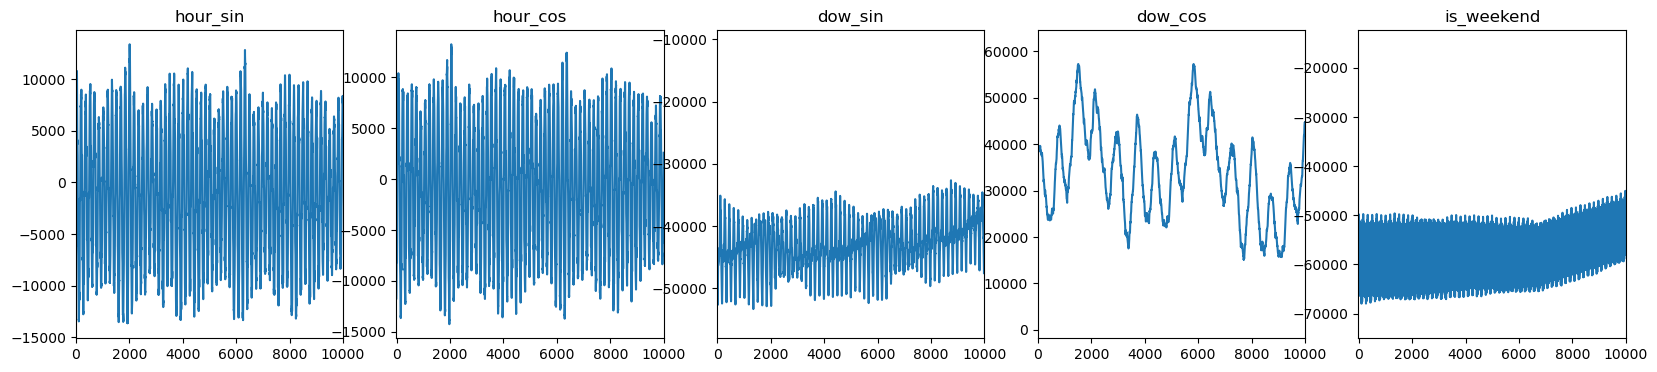

In [263]:
fig, axs = plt.subplots(1,5, figsize=(20,4))
lags = correlation_lags(len(new_res), len(new_res), mode="same")

for i in range(5):
    corr = np.correlate(res, X_val_imputed[:,2+i], mode="same")
    axs[i].plot(lags, corr)
    axs[i].set_title(df_val.columns.to_list()[2+i])
    axs[i].set_xlim(-10,10000)

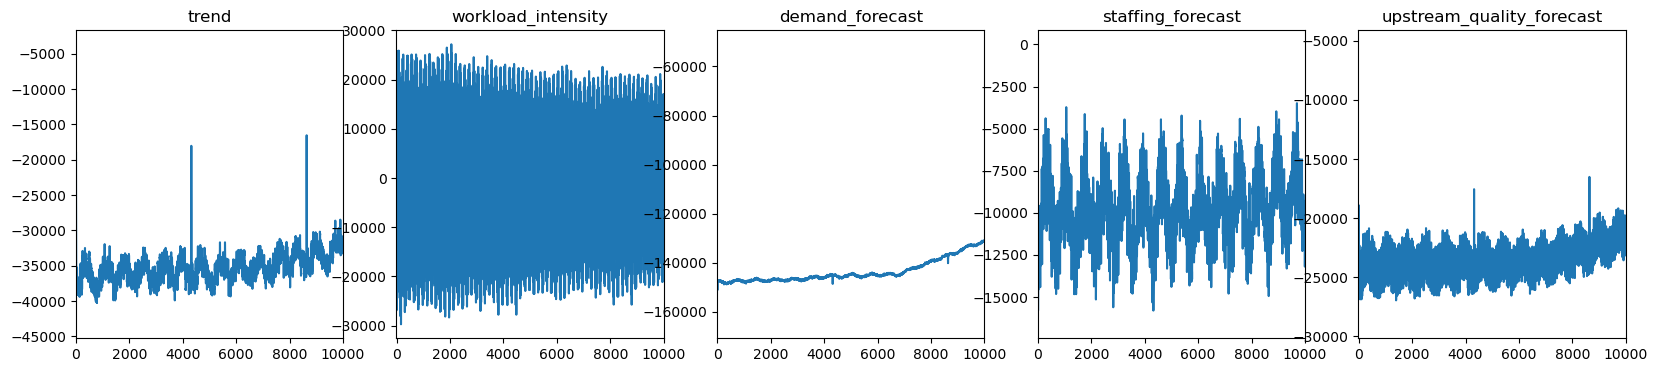

In [264]:
fig, axs = plt.subplots(1,5, figsize=(20,4))
for i in range(5, 10):
    corr = np.correlate(res, X_val_imputed[:,2+i], mode="same")
    axs[i-5].plot(lags, corr)
    axs[i-5].set_title(df_val.columns.to_list()[2+i])
    axs[i-5].set_xlim(-10,10000)

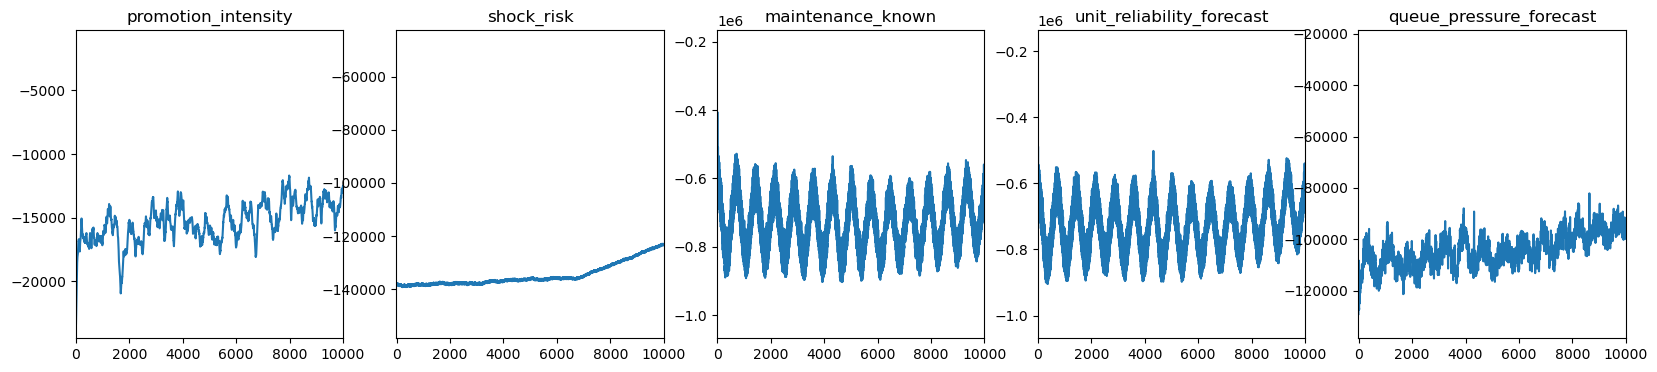

In [265]:
fig, axs = plt.subplots(1,5, figsize=(20,4))
for i in range(10, 15):
    corr = np.correlate(res, X_val_imputed[:,2+i], mode="same")
    axs[i-10].plot(lags, corr)
    axs[i-10].set_title(df_val.columns.to_list()[2+i])
    axs[i-10].set_xlim(-10,10000)